# Support Ticket Triage : Machine Learning Modeling

This notebook trains and evaluates two supervised NLP classifiers:

1. **Issue Type Classification** — predicts `incident`, `request`, `problem`, or `change`
2. **Priority Classification** — predicts `high`, `medium`, or `low`

The workflow uses:
- TF-IDF text features
- Baseline comparison
- Logistic Regression
- Linear SVM
- Multinomial Naive Bayes
- SGD Classifier
- Complement Naive Bayes
- Stratified train/test split
- 5-fold cross-validation
- Randomized hyperparameter tuning
- Macro-F1 for Issue Type
- Multi-metric evaluation for Priority
- Business penalty analysis
- Error analysis
- Saving final trained models

> The held-out test set is used only for final evaluation. Model selection is based on cross-validation results from the training data.

In [1]:
 # 1. IMPORTS 
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)



In [2]:
 #1.1 Configuration
 
FILE_PATH = "../Downloads/ml_ready_support_tickets.csv"

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_ITER_SEARCH = 15

PRIORITY_LABELS = ["high", "medium", "low"]

# Minimum class-recall constraints for a priority model to be considered operationally acceptable.
MIN_HIGH_RECALL = 0.55
MIN_LOW_RECALL = 0.30

## 2. Load and Validate the Modeling Dataset

The modeling file should come from the EDA/preparation notebook and contain:
`subject`, `body`, `text`, `type`, and `priority`.

In [3]:
 # 2. LOAD DATA
 
df = pd.read_csv(FILE_PATH)

required_columns = ["subject", "body", "text", "type", "priority"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Safety checks
df = df.dropna(subset=["text", "type", "priority"]).copy()

df["text"] = df["text"].astype(str).str.strip()
df["type"] = df["type"].astype(str).str.strip().str.lower()
df["priority"] = df["priority"].astype(str).str.strip().str.lower()

df = df[df["text"].str.len() > 0].copy()

print("Modeling dataset shape:", df.shape)

print("\nIssue Type distribution:")
print(df["type"].value_counts())

print("\nPriority distribution:")
print(df["priority"].value_counts())

Modeling dataset shape: (17217, 5)

Issue Type distribution:
incident    6843
request     5028
problem     3555
change      1791
Name: type, dtype: int64

Priority distribution:
medium    7134
high      6582
low       3501
Name: priority, dtype: int64


## 3. Priority Business Cost

The priority task includes a business penalty matrix.

A severe under-prioritization is more costly than an over-prioritization. In particular, predicting a truly **High** ticket as **Low** receives the largest penalty.

The business cost is reported alongside predictive metrics. It is **not allowed to hide extremely poor class recall**.

In [5]:
 # 3. PRIORITY COST MATRIX



PRIORITY_COST_MATRIX = np.array([
    [0, 20, 100],
    [5, 0, 20],
    [5, 5, 0]
])


def priority_cost(y_true, y_pred):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=PRIORITY_LABELS
    )

    total_cost = np.sum(
        cm * PRIORITY_COST_MATRIX
    )

    return total_cost


def priority_cost_per_ticket(y_true, y_pred):
    if len(y_true) == 0:
        return 0.0

    return priority_cost(y_true, y_pred) / len(y_true)


priority_cost_scorer = make_scorer(
    priority_cost_per_ticket,
    greater_is_better=False
)

## 4. Reusable Evaluation Functions

In [6]:
 # 4. EVALUATION FUNCTIONS
 
def per_class_metrics_dict(y_true, y_pred, labels):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0
    )

    metrics = {}

    for label, p, r, f in zip(labels, precision, recall, f1):
        metrics[f"{label}_precision"] = p
        metrics[f"{label}_recall"] = r
        metrics[f"{label}_f1"] = f

    return metrics


def evaluate_predictions(y_true, y_pred, labels):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    }

    metrics.update(
        per_class_metrics_dict(
            y_true,
            y_pred,
            labels
        )
    )

    return metrics

## 5. Candidate Pipelines and Hyperparameter Spaces

TF-IDF is placed inside each pipeline so it is fitted separately inside each cross-validation fold, which prevents information leakage.

In [8]:
# 5. MODELS


baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)


candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        dual="auto",
        random_state=RANDOM_STATE
    ),

    "Multinomial Naive Bayes": MultinomialNB(),

    "SGD Classifier": SGDClassifier(
        loss="hinge",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "Complement Naive Bayes": ComplementNB()
}


def make_pipeline(model):
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True
            )
        ),
        ("model", model)
    ])


parameter_spaces = {
    "Logistic Regression": {
        "tfidf__max_df": [0.90, 0.95, 1.0],
        "tfidf__min_df": [1, 2, 3, 5],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "model__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    },

    "Linear SVM": {
        "tfidf__max_df": [0.90, 0.95, 1.0],
        "tfidf__min_df": [1, 2, 3, 5],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "model__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10]
    },

    "Multinomial Naive Bayes": {
        "tfidf__max_df": [0.90, 0.95, 1.0],
        "tfidf__min_df": [1, 2, 3, 5],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2]
    },

    "SGD Classifier": {
        "tfidf__max_df": [0.90, 0.95, 1.0],
        "tfidf__min_df": [1, 2, 3, 5],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
    },

    "Complement Naive Bayes": {
        "tfidf__max_df": [0.90, 0.95, 1.0],
        "tfidf__min_df": [1, 2, 3, 5],
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__sublinear_tf": [True, False],
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2]
    }
}

## 6. Modeling Function

Important methodology improvement:

- **Issue Type:** model selection uses cross-validation Macro-F1.
- **Priority:** each candidate records both cross-validation business cost and cross-validation Macro-F1.
- The held-out test set is evaluated only after the winner is selected.
- Priority selection also applies minimum recall constraints to avoid choosing a model that effectively abandons one class.

In [9]:
 # 6. MODELING FUNCTION
 
def run_classification(X, y, target_name):

    print("=" * 80)
    print(f"STARTING CLASSIFICATION: {target_name}")
    print("=" * 80)

    # --------------------------------------------------------------------------
    # Train / Test split
    # --------------------------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    print("Training samples:", len(X_train))
    print("Testing samples :", len(X_test))

    class_labels = (
        PRIORITY_LABELS
        if target_name == "Priority"
        else sorted(y.unique())
    )

    cv_strategy = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------------------------
    # Baseline
    # --------------------------------------------------------------------------

    baseline_pipeline = make_pipeline(baseline_model)

    baseline_pipeline.fit(
        X_train,
        y_train
    )

    baseline_pred = baseline_pipeline.predict(X_test)

    baseline_metrics = evaluate_predictions(
        y_test,
        baseline_pred,
        class_labels
    )

    baseline_row = {
        "Model": "Baseline (Majority Class)",
        "Role": "Baseline",
        "CV Primary Score": np.nan,
        "CV Macro F1": np.nan,
        **baseline_metrics
    }

    if target_name == "Priority":
        baseline_row["Test Penalty Cost"] = priority_cost(
            y_test,
            baseline_pred
        )
        baseline_row["Test Cost Per Ticket"] = priority_cost_per_ticket(
            y_test,
            baseline_pred
        )

    # --------------------------------------------------------------------------
    # Candidate tuning — CV ONLY
    # --------------------------------------------------------------------------

    cv_rows = []
    fitted_searches = {}

    for model_name, model in candidate_models.items():

        print("\n" + "-" * 80)
        print("Tuning:", model_name)
        print("-" * 80)

        pipeline = make_pipeline(model)

        if target_name == "Priority":
            scoring = {
                "business_cost": priority_cost_scorer,
                "macro_f1": "f1_macro"
            }

            refit_metric = "business_cost"

        else:
            scoring = {
                "macro_f1": "f1_macro"
            }

            refit_metric = "macro_f1"

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=parameter_spaces[model_name],
            n_iter=N_ITER_SEARCH,
            scoring=scoring,
            refit=refit_metric,
            cv=cv_strategy,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            return_train_score=False
        )

        search.fit(
            X_train,
            y_train
        )

        fitted_searches[model_name] = search

        best_idx = search.best_index_

        cv_macro_f1 = search.cv_results_[
            "mean_test_macro_f1"
        ][best_idx]

        row = {
            "Model": model_name,
            "CV Macro F1": cv_macro_f1,
            "Best Parameters": search.best_params_
        }

        if target_name == "Priority":
            # Scorer is negative because greater_is_better=False.
            # Convert back to positive average penalty per ticket.
            cv_cost_per_ticket = -search.best_score_

            row["CV Cost Per Ticket"] = cv_cost_per_ticket
            row["CV Primary Score"] = search.best_score_

        else:
            row["CV Primary Score"] = search.best_score_

        cv_rows.append(row)

        print("Best CV Macro F1:", round(cv_macro_f1, 4))

        if target_name == "Priority":
            print(
                "Best CV Cost Per Ticket:",
                round(cv_cost_per_ticket, 4)
            )

        print("Best Parameters:", search.best_params_)

    cv_results_df = pd.DataFrame(cv_rows)

    # --------------------------------------------------------------------------
    # Winner selection — TRAIN/CV DATA ONLY
    # --------------------------------------------------------------------------

    if target_name == "Issue Type":

        selected_row = (
            cv_results_df
            .sort_values(
                "CV Macro F1",
                ascending=False
            )
            .iloc[0]
        )

        winner_name = selected_row["Model"]

    else:
        # First obtain out-of-fold-like validation behavior from the best
        # CV-tuned candidate by using the refit model on training data only
        # to estimate class balance constraints conservatively.
        #
        # We do NOT use the final held-out test metrics to choose the winner.
        priority_selection_rows = []

        for model_name, search in fitted_searches.items():

            best_model = search.best_estimator_

            # Training predictions here are not used as final performance metrics.
            # They are used only as a safety filter for gross class collapse.
            train_pred = best_model.predict(X_train)

            train_class_metrics = per_class_metrics_dict(
                y_train,
                train_pred,
                PRIORITY_LABELS
            )

            cv_row = cv_results_df[
                cv_results_df["Model"] == model_name
            ].iloc[0].to_dict()

            cv_row["screen_high_recall"] = train_class_metrics["high_recall"]
            cv_row["screen_low_recall"] = train_class_metrics["low_recall"]

            priority_selection_rows.append(cv_row)

        priority_selection_df = pd.DataFrame(
            priority_selection_rows
        )

        eligible = priority_selection_df[
            (priority_selection_df["screen_high_recall"] >= MIN_HIGH_RECALL)
            &
            (priority_selection_df["screen_low_recall"] >= MIN_LOW_RECALL)
        ].copy()

        if eligible.empty:
            print(
                "\nWARNING: No priority candidate met the minimum recall "
                "constraints. Falling back to CV Macro-F1."
            )

            selected_row = (
                priority_selection_df
                .sort_values(
                    "CV Macro F1",
                    ascending=False
                )
                .iloc[0]
            )

        else:
            # Among operationally acceptable models:
            # 1) minimize business cost
            # 2) use CV Macro-F1 as tie-breaker
            selected_row = (
                eligible
                .sort_values(
                    by=[
                        "CV Cost Per Ticket",
                        "CV Macro F1"
                    ],
                    ascending=[
                        True,
                        False
                    ]
                )
                .iloc[0]
            )

        winner_name = selected_row["Model"]

    winner_model = fitted_searches[
        winner_name
    ].best_estimator_

    # --------------------------------------------------------------------------
    # Final TEST evaluation — only after winner selection
    # --------------------------------------------------------------------------

    test_pred = winner_model.predict(X_test)

    winner_metrics = evaluate_predictions(
        y_test,
        test_pred,
        class_labels
    )

    winner_row = {
        "Model": winner_name,
        "Role": "Winner",
        "CV Primary Score": selected_row["CV Primary Score"],
        "CV Macro F1": selected_row["CV Macro F1"],
        **winner_metrics,
        "Best Parameters": fitted_searches[winner_name].best_params_
    }

    if target_name == "Priority":
        winner_row["CV Cost Per Ticket"] = selected_row[
            "CV Cost Per Ticket"
        ]

        winner_row["Test Penalty Cost"] = priority_cost(
            y_test,
            test_pred
        )

        winner_row["Test Cost Per Ticket"] = priority_cost_per_ticket(
            y_test,
            test_pred
        )

    comparison_df = pd.DataFrame([
        baseline_row,
        winner_row
    ])

    # --------------------------------------------------------------------------
    # Classification Report
    # --------------------------------------------------------------------------

    print("\n" + "=" * 80)
    print("WINNER MODEL:", winner_name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            test_pred,
            labels=class_labels,
            zero_division=0
        )
    )

    # --------------------------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        test_pred,
        labels=class_labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            f"Actual_{label}"
            for label in class_labels
        ],
        columns=[
            f"Predicted_{label}"
            for label in class_labels
        ]
    )

    display(cm_df)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_labels
    )

    disp.plot(
        values_format="d"
    )

    plt.title(
        f"Confusion Matrix — {target_name}"
    )
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------------------
    # Prediction-level error analysis
    # --------------------------------------------------------------------------

    prediction_df = pd.DataFrame({
        "text": X_test.reset_index(drop=True),
        "actual": y_test.reset_index(drop=True),
        "predicted": pd.Series(test_pred)
    })

    prediction_df["correct"] = (
        prediction_df["actual"]
        ==
        prediction_df["predicted"]
    )

    prediction_df["error_type"] = np.where(
        prediction_df["correct"],
        "Correct",
        prediction_df["actual"]
        + "_to_"
        + prediction_df["predicted"]
    )

    return {
        "target_name": target_name,
        "winner_name": winner_name,
        "winner_model": winner_model,
        "cv_results": cv_results_df,
        "comparison": comparison_df,
        "confusion_matrix": cm_df,
        "predictions": prediction_df,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

## 7. Train the Issue Type Classifier

STARTING CLASSIFICATION: Issue Type
Training samples: 13773
Testing samples : 3444

--------------------------------------------------------------------------------
Tuning: Logistic Regression
--------------------------------------------------------------------------------
Best CV Macro F1: 0.8558
Best Parameters: {'tfidf__sublinear_tf': False, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 1, 'tfidf__max_df': 0.95, 'model__C': 50}

--------------------------------------------------------------------------------
Tuning: Linear SVM
--------------------------------------------------------------------------------
Best CV Macro F1: 0.8445
Best Parameters: {'tfidf__sublinear_tf': False, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 3, 'tfidf__max_df': 1.0, 'model__C': 5}

--------------------------------------------------------------------------------
Tuning: Multinomial Naive Bayes
--------------------------------------------------------------------------------
Best CV Macro F1: 0.8249
Be

,Predicted_change,Predicted_incident,Predicted_problem,Predicted_request
Actual_change,341,1,2,14
Actual_incident,2,1153,214,0
Actual_problem,0,229,481,1
Actual_request,6,0,1,999


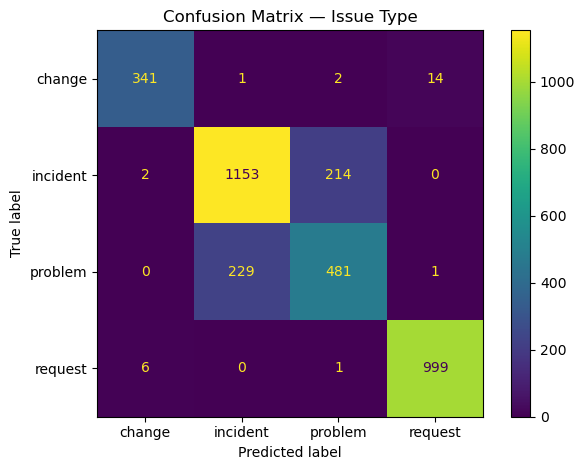


Issue Type CV Results


,Model,CV Macro F1,Best Parameters,CV Primary Score
0,Logistic Regression,0.855764,"{'tfidf__sublinear_tf': False, 'tfidf__ngram_r...",0.855764
3,SGD Classifier,0.848115,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_ra...",0.848115
1,Linear SVM,0.844543,"{'tfidf__sublinear_tf': False, 'tfidf__ngram_r...",0.844543
2,Multinomial Naive Bayes,0.824889,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_ra...",0.824889
4,Complement Naive Bayes,0.734441,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_ra...",0.734441



Final Issue Type Comparison


,Model,Role,CV Primary Score,CV Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,change_precision,change_recall,...,incident_precision,incident_recall,incident_f1,problem_precision,problem_recall,problem_f1,request_precision,request_recall,request_f1,Best Parameters
0,Baseline (Majority Class),Baseline,NaN,NaN,0.397503,0.099376,0.250000,0.142219,0.000000,0.000000,...,0.397503,1.000000,0.568876,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1,Logistic Regression,Winner,0.855764,0.855764,0.863531,0.871273,0.866072,0.868610,0.977077,0.952514,...,0.833695,0.842221,0.837936,0.689112,0.676512,0.682754,0.985207,0.993042,0.989109,"{'tfidf__sublinear_tf': False, 'tfidf__ngram_r..."


In [10]:
# ==============================================================================
# 7. ISSUE TYPE CLASSIFICATION
# ==============================================================================

issue_type_results = run_classification(
    X=df["text"],
    y=df["type"],
    target_name="Issue Type"
)

print("\nIssue Type CV Results")
display(
    issue_type_results["cv_results"]
    .sort_values(
        "CV Macro F1",
        ascending=False
    )
)

print("\nFinal Issue Type Comparison")
display(
    issue_type_results["comparison"]
)

## 8. Issue Type Error Analysis

In [11]:
# ==============================================================================
# 8. ISSUE TYPE ERROR ANALYSIS
# ==============================================================================

issue_type_predictions = issue_type_results[
    "predictions"
]

issue_type_errors = issue_type_predictions[
    ~issue_type_predictions["correct"]
]

print("Most common Issue Type errors:")
display(
    issue_type_errors[
        "error_type"
    ]
    .value_counts()
    .head(10)
    .to_frame("count")
)

print("\nSample misclassified tickets:")
display(
    issue_type_errors[
        ["text", "actual", "predicted", "error_type"]
    ]
    .head(15)
)

Most common Issue Type errors:


,count
problem_to_incident,229
incident_to_problem,214
change_to_request,14
request_to_change,6
incident_to_change,2
change_to_problem,2
request_to_problem,1
change_to_incident,1
problem_to_request,1



Sample misclassified tickets:


,text,actual,predicted,error_type
3,Observation of Campaign Efficiency Decline Mar...,problem,incident,problem_to_incident
15,Support Inquiry Regarding Data Analytics Dashb...,problem,incident,problem_to_incident
23,Data Leak Incident An unexpected data leak has...,problem,incident,problem_to_incident
44,Marketing Growth Challenges Increase The marke...,problem,incident,problem_to_incident
60,Immediate Attention Needed: Malfunction in Cru...,incident,problem,incident_to_problem
70,Support Brand Engagement Concern Noticing a de...,incident,problem,incident_to_problem
71,Potential Data Compromise A potential data com...,problem,incident,problem_to_incident
76,Inaccurate investment forecasts linked to pote...,problem,incident,problem_to_incident
78,Facing Problems with Digital Marketing Softwar...,problem,incident,problem_to_incident
91,Simultaneous Failure of Multiple Software and ...,problem,incident,problem_to_incident


## 9. Train the Priority Classifier

STARTING CLASSIFICATION: Priority
Training samples: 13773
Testing samples : 3444

--------------------------------------------------------------------------------
Tuning: Logistic Regression
--------------------------------------------------------------------------------
Best CV Macro F1: 0.6067
Best CV Cost Per Ticket: 7.1375
Best Parameters: {'tfidf__sublinear_tf': False, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 1, 'tfidf__max_df': 0.95, 'model__C': 50}

--------------------------------------------------------------------------------
Tuning: Linear SVM
--------------------------------------------------------------------------------
Best CV Macro F1: 0.4044
Best CV Cost Per Ticket: 5.6462
Best Parameters: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 3, 'tfidf__max_df': 1.0, 'model__C': 0.01}

--------------------------------------------------------------------------------
Tuning: Multinomial Naive Bayes
--------------------------------------------

,Predicted_high,Predicted_medium,Predicted_low
Actual_high,907,300,110
Actual_medium,299,977,151
Actual_low,132,174,394


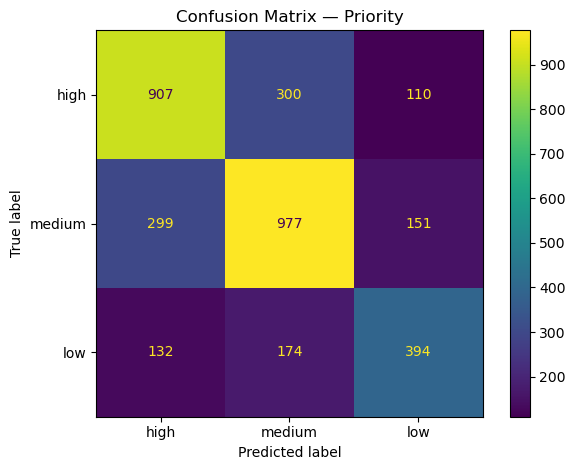


Priority CV Results


,Model,CV Macro F1,Best Parameters,CV Cost Per Ticket,CV Primary Score
4,Complement Naive Bayes,0.410619,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_ra...",5.080225,-5.080225
2,Multinomial Naive Bayes,0.379216,"{'tfidf__sublinear_tf': False, 'tfidf__ngram_r...",5.092930,-5.092930
1,Linear SVM,0.404357,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_ra...",5.646186,-5.646186
0,Logistic Regression,0.606677,"{'tfidf__sublinear_tf': False, 'tfidf__ngram_r...",7.137487,-7.137487
3,SGD Classifier,0.598401,"{'tfidf__sublinear_tf': True, 'tfidf__ngram_ra...",7.540446,-7.540446



Final Priority Comparison


,Model,Role,CV Primary Score,CV Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,high_precision,high_recall,...,medium_precision,medium_recall,medium_f1,low_precision,low_recall,low_f1,Test Penalty Cost,Test Cost Per Ticket,Best Parameters,CV Cost Per Ticket
0,Baseline (Majority Class),Baseline,NaN,NaN,0.414344,0.138115,0.333333,0.195306,0.000000,0.000000,...,0.414344,1.000000,0.585917,0.000000,0.000000,0.00000,29840,8.664344,NaN,NaN
1,Logistic Regression,Winner,-7.137487,0.606677,0.661440,0.650911,0.645399,0.647911,0.677877,0.688686,...,0.673329,0.684653,0.678944,0.601527,0.562857,0.58155,23045,6.691347,"{'tfidf__sublinear_tf': False, 'tfidf__ngram_r...",7.137487


In [12]:
# ==============================================================================
# 9. PRIORITY CLASSIFICATION
# ==============================================================================

priority_results = run_classification(
    X=df["text"],
    y=df["priority"],
    target_name="Priority"
)

print("\nPriority CV Results")
display(
    priority_results["cv_results"]
    .sort_values(
        ["CV Cost Per Ticket", "CV Macro F1"],
        ascending=[True, False]
    )
)

print("\nFinal Priority Comparison")
display(
    priority_results["comparison"]
)

## 10. Priority Error Analysis

For the priority model, pay particular attention to severe under-prioritization such as `high_to_low`.

In [13]:
# ==============================================================================
# 10. PRIORITY ERROR ANALYSIS
# ==============================================================================

priority_predictions = priority_results[
    "predictions"
]

priority_errors = priority_predictions[
    ~priority_predictions["correct"]
]

print("Priority error types:")
display(
    priority_errors[
        "error_type"
    ]
    .value_counts()
    .to_frame("count")
)

high_to_low = priority_errors[
    priority_errors["error_type"]
    ==
    "high_to_low"
]

print(
    "\nNumber of High → Low errors:",
    len(high_to_low)
)

print("\nSample High → Low tickets:")
display(
    high_to_low[
        ["text", "actual", "predicted"]
    ]
    .head(10)
)

Priority error types:


,count
high_to_medium,300
medium_to_high,299
low_to_medium,174
medium_to_low,151
low_to_high,132
high_to_low,110



Number of High → Low errors: 110

Sample High → Low tickets:


,text,actual,predicted
1,System Performance Issue Due to Network Conges...,high,low
9,"Growth Strategies in Digital Customer Support,...",high,low
12,Problem with Investment Analysis Software The ...,high,low
58,Assistance with Securely Connecting to QuickBo...,high,low
151,Query on Data Analytics Services Could you pro...,high,low
153,Digital Campaigns Fail to Expand Preparing a r...,high,low
156,Marketing Assistance Needed The digital strate...,high,low
160,Report on Unusual Billing Issue An unexpected ...,high,low
161,Recent Breach in Medical Data Security Discove...,high,low
188,Enhancing Medical Data Security It is crucial ...,high,low


## 11. Final System Summary

In [14]:
# ==============================================================================
# 11. FINAL SYSTEM SUMMARY
# ==============================================================================

summary_rows = []

for results in [
    issue_type_results,
    priority_results
]:
    winner = results["comparison"][
        results["comparison"]["Role"] == "Winner"
    ].iloc[0]

    row = {
        "Target": results["target_name"],
        "Winner Model": results["winner_name"],
        "Accuracy": winner["Accuracy"],
        "Macro Precision": winner["Macro Precision"],
        "Macro Recall": winner["Macro Recall"],
        "Macro F1": winner["Macro F1"],
        "CV Macro F1": winner["CV Macro F1"]
    }

    if results["target_name"] == "Priority":
        row["CV Cost Per Ticket"] = winner[
            "CV Cost Per Ticket"
        ]
        row["Test Penalty Cost"] = winner[
            "Test Penalty Cost"
        ]
        row["Test Cost Per Ticket"] = winner[
            "Test Cost Per Ticket"
        ]

    summary_rows.append(row)

final_summary = pd.DataFrame(summary_rows)

display(final_summary)

,Target,Winner Model,Accuracy,Macro Precision,Macro Recall,Macro F1,CV Macro F1,CV Cost Per Ticket,Test Penalty Cost,Test Cost Per Ticket
0,Issue Type,Logistic Regression,0.863531,0.871273,0.866072,0.868610,0.855764,NaN,NaN,NaN
1,Priority,Logistic Regression,0.661440,0.650911,0.645399,0.647911,0.606677,7.137487,23045.0,6.691347


## 12. Save Models and Evaluation Outputs

The saved pipeline includes both TF-IDF and the trained classifier, so new tickets can be passed directly as raw text.

In [15]:
# ==============================================================================
# 12. SAVE MODELS & OUTPUTS
# ==============================================================================

joblib.dump(
    issue_type_results["winner_model"],
    "issue_type_model.joblib"
)

joblib.dump(
    priority_results["winner_model"],
    "priority_model.joblib"
)

issue_type_results["cv_results"].to_csv(
    "issue_type_cv_results.csv",
    index=False
)

issue_type_results["comparison"].to_csv(
    "issue_type_final_comparison.csv",
    index=False
)

issue_type_results["confusion_matrix"].to_csv(
    "issue_type_confusion_matrix.csv"
)

issue_type_results["predictions"].to_csv(
    "issue_type_test_predictions.csv",
    index=False
)

priority_results["cv_results"].to_csv(
    "priority_cv_results.csv",
    index=False
)

priority_results["comparison"].to_csv(
    "priority_final_comparison.csv",
    index=False
)

priority_results["confusion_matrix"].to_csv(
    "priority_confusion_matrix.csv"
)

priority_results["predictions"].to_csv(
    "priority_test_predictions.csv",
    index=False
)

final_summary.to_csv(
    "final_model_summary.csv",
    index=False
)

print("Models and evaluation files saved successfully.")

Models and evaluation files saved successfully.


## 13. Test the Final Models on a New Ticket

In [16]:
# ==============================================================================
# 13. PREDICT A NEW TICKET
# ==============================================================================

def predict_ticket(subject, body):
    ticket_text = f"{subject} {body}".strip()

    predicted_type = issue_type_results[
        "winner_model"
    ].predict([ticket_text])[0]

    predicted_priority = priority_results[
        "winner_model"
    ].predict([ticket_text])[0]

    return {
        "ticket_text": ticket_text,
        "predicted_type": predicted_type,
        "predicted_priority": predicted_priority
    }


example_prediction = predict_ticket(
    subject="VPN access is down",
    body="I am unable to connect to the company VPN and need immediate access."
)

example_prediction

{'ticket_text': 'VPN access is down I am unable to connect to the company VPN and need immediate access.',
 'predicted_type': 'problem',
 'predicted_priority': 'high'}